In [1]:
import os
import sys

sys.path.insert(0, os.path.join("..", "..", "src"))

import numpy as np
import torch
from tqdm import tqdm

from hic_dataset import SubmatrixDataset
from hic_model import SimpleEnhanceCNN, HiCFoundationHead
from hic_train import (
    compute_ssim_scores,
    load_or_compute_scores,
    plot_ssim_violin_5way,
    plot_score_scatter,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

test_dataset = SubmatrixDataset(os.path.join("..", "..", "results", "submatrices", "frac_0.05", "test.h5"))
print(f"Test dataset size: {len(test_dataset)}")

cache_dir = os.path.join("..", "..", "results", "score_cache")

Using device: cuda
Test dataset size: 5026


In [2]:
cnn_run_date = "2026-07-30"
cnn_model_path = os.path.join("..", "..", "results", "training", cnn_run_date, "model.pt")

cnn_model = SimpleEnhanceCNN()
cnn_model.load_state_dict(torch.load(cnn_model_path, map_location=device))
cnn_model.to(device).eval()

input_ssim, cnn_ssim = load_or_compute_scores(
    os.path.join(cache_dir, "ssim_cnn.npz"),
    compute_ssim_scores, cnn_model, test_dataset, device
)
print(f"Input SSIM: mean={input_ssim.mean():.4f}, std={input_ssim.std():.4f}")
print(f"CNN SSIM:   mean={cnn_ssim.mean():.4f}, std={cnn_ssim.std():.4f}")

Loading cached scores from ..\results\score_cache\ssim_cnn.npz
Input SSIM: mean=0.1360, std=0.0490
CNN SSIM:   mean=0.3297, std=0.0257


C:\Users\momoh\AppData\Local\Temp\ipykernel_34876\266690391.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(cnn_model_path, map_loca

In [3]:
hicf_run_date = "2026-08-11"
hicf_weights = os.path.join("..", "..", "hicfoundation_model", "hicfoundation_pretrain.pth.tar")

hicf_ssim = {}

for layers in [1, 4, 8]:
    model_path = os.path.join("..", "..", "results", f"training_hicfoundation_{layers}layer", hicf_run_date, "model.pt")

    model = HiCFoundationHead(hicf_weights, decoder_layers=layers)
    state_dict = torch.load(model_path, map_location=device)

    if any(k.startswith("_orig_mod.") for k in state_dict.keys()):
        state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}

    model.load_state_dict(state_dict, strict=False)
    model.to(device).eval()

    _, hicf_ssim[layers] = load_or_compute_scores(
        os.path.join(cache_dir, f"ssim_hicf_{layers}layer.npz"),
        compute_ssim_scores, model, test_dataset, device
    )
    print(f"HiCFoundation {layers}-layer: mean={hicf_ssim[layers].mean():.4f}, std={hicf_ssim[layers].std():.4f}")

print("\nAll models scored")

C:\Users\momoh\AppData\Local\Temp\ipykernel_34876\2550447206.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location=device)


Loading cached scores from ..\results\score_cache\ssim_hicf_1layer.npz
HiCFoundation 1-layer: mean=0.3391, std=0.0257
Loading cached scores from ..\results\score_cache\ssim_hicf_4layer.npz
HiCFoundation 4-layer: mean=0.3406, std=0.0243
Loading cached scores from ..\results\score_cache\ssim_hicf_8layer.npz
HiCFoundation 8-layer: mean=0.3427, std=0.0272

All models scored


In [4]:
all_scores_ssim = {
    "Input": input_ssim,
    "CNN": cnn_ssim,
    "HiCFoundation (1-layer)": hicf_ssim[1],
    "HiCFoundation (4-layer)": hicf_ssim[4],
    "HiCFoundation (8-layer)": hicf_ssim[8],
}

comparison_dir = os.path.join("..", "..", "results", "plots", "ssim_analysis")
os.makedirs(comparison_dir, exist_ok=True)

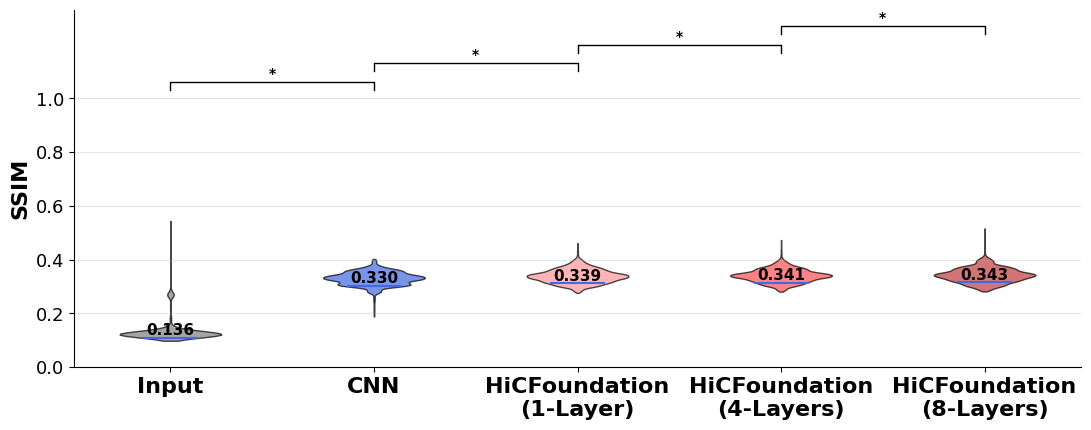

In [5]:
plot_ssim_violin_5way(
    all_scores_ssim, metric_name="SSIM",
    save_path=os.path.join(comparison_dir, "violin_plot_all_models.png"),
    pairs=[
        ("Input", "CNN"),
        ("CNN", "HiCFoundation (1-layer)"),
        ("HiCFoundation (1-layer)", "HiCFoundation (4-layer)"),
        ("HiCFoundation (4-layer)", "HiCFoundation (8-layer)")
    ]
)

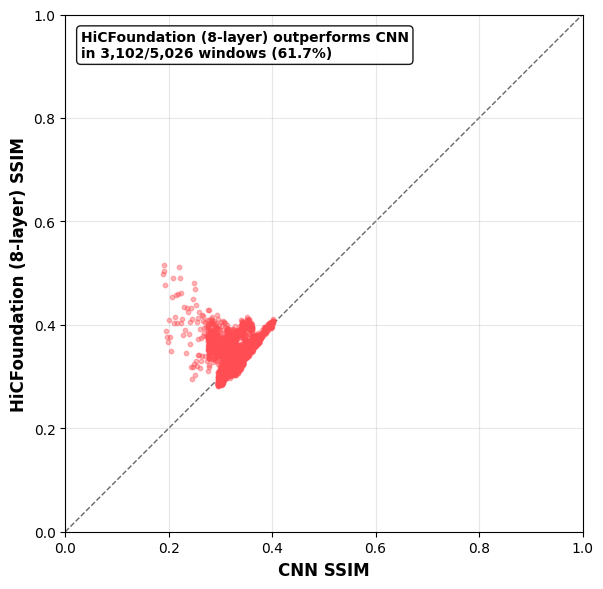

In [6]:
plot_score_scatter(
    cnn_ssim, hicf_ssim[8],
    label_x="CNN", label_y="HiCFoundation (8-layer)", metric_name="SSIM",
    save_path=os.path.join(comparison_dir, "scatter_cnn_vs_hicf_8layer.png")
)

test_dataset.close()